# The Annular Membrane
## Phantom eigenmodes in a circular waveguide: Bessel-Neumann modes, inner wall reflections, and sparser radial mode spacing
*Working Document — April 2026 · Toy Models series — Part 4 of 4*

---

## Preface: Why the Annulus

The annular membrane is the disk with a hole in the middle. Adding an inner boundary changes three things: the radial eigenfunctions now involve both Bessel functions $J_n$ and Neumann functions $Y_n$, the radial mode spacing at fixed azimuthal order increases (modes are sparser) because the annular cavity has smaller radial depth, and the phantom structure near the inner wall is qualitatively different from the disk.

The angular structure is identical to the disk — the same $2\times 2$ $B_\lambda$ matrix, the same $\beta_{\pm}$ formula, the same accidental zeros. The only change is the radial factor $\rho_{nm}$, which is computed with the annular radial eigenfunctions $R_{nm}(r)$ rather than $J_n(k_{nm}r)$. This makes the annulus the simplest extension of the disk framework: everything is the same except the radial functions.

The annulus also models a class of practically important structures: circular rings, cylindrical shells, annular plates, and bearing races. The phantom eigenmode analysis for these structures requires the annular framework rather than the disk framework.

Two limiting cases are worked out explicitly: the disk limit ($r_{in}\to 0$) and the thin-ring limit ($r_{out}-r_{in}\to 0$). The first recovers the disk results exactly. The second reduces the 2D problem to an effective 1D angular problem at fixed radial mode index, after projection to the lowest radial mode and subtraction of the diverging $(\pi/\delta)^2$ radial energy (or, equivalently, under Neumann radial boundary conditions).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from scipy.special import jv, yv, jn_zeros
from scipy.integrate import quad
from scipy.optimize import brentq

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,
    'axes.spines.right':False,'figure.facecolor':'white','axes.facecolor':'#f8f8f6',
    'grid.color':'white','grid.linewidth':1.2})
np.random.seed(42)
BLUE='#1a5fa8'; AMBER='#b85c00'; GREEN='#2a8c3a'; RED='#cc2222'; PURP='#8844aa'

def bt(ax,x,y,txt,zorder=6,**kw):
    kw.setdefault('fontweight','heavy'); kw.setdefault('color','black'); kw.setdefault('fontsize',10)
    t=ax.text(x,y,txt,zorder=zorder,**kw)
    t.set_path_effects([pe.withStroke(linewidth=3,foreground='white')]); return t

def secular(k, n, r_in, r_out):
    return jv(n,k*r_in)*yv(n,k*r_out) - yv(n,k*r_in)*jv(n,k*r_out)

def ann_eigenvalues(n, r_in, r_out, n_modes=5):
    """Find first n_modes zeros of secular equation."""
    k_disk = jn_zeros(n, n_modes+2)/r_out
    zeros = []
    k_search = np.linspace(np.pi/(r_out-r_in)*0.5, np.pi/(r_out-r_in)*(n_modes+3), 5000)
    f_vals = secular(k_search, n, r_in, r_out)
    for i in range(len(k_search)-1):
        if f_vals[i]*f_vals[i+1] < 0:
            try:
                z = brentq(secular, k_search[i], k_search[i+1], args=(n, r_in, r_out))
                zeros.append(z)
            except: pass
        if len(zeros) >= n_modes: break
    return np.array(zeros[:n_modes])

def R_nm(r, k, n, r_in):
    return jv(n,k*r)*yv(n,k*r_in) - yv(n,k*r)*jv(n,k*r_in)

def rho_ann(n, k, r_in, r_out, r1, r2):
    """Radial overlap: c^2 * integral_{r1}^{r2} R^2 r dr.
    Uses complex-basis normalization c^2 = 1/(2pi * integral_{r_in}^{r_out} R^2 r dr),
    so rho = val / (2*pi*norm). This matches the disk formula rho_disk = c^2 * V
    and ensures beta_+- in [0,1] with full-domain full-angle giving beta=1.
    """
    def integrand(r): return R_nm(r, k, n, r_in)**2 * r
    norm, _ = quad(integrand, r_in, r_out)
    val, _ = quad(integrand, r1, r2)
    return val / (2 * np.pi * norm) if norm > 0 else 0

def beta_pm_ann(n, k, r_in, r_out, r1, r2, Delta_theta):
    rho = rho_ann(n, k, r_in, r_out, r1, r2)
    split = abs(np.sin(n*Delta_theta))/n if n > 0 else 0
    return rho*(Delta_theta+split), rho*(Delta_theta-split), rho

print("Imports OK — annular membrane")


Imports OK — annular membrane


---
## Part I — Setup

### 1.1 Domain

Annular domain $\Omega=\{(r,\theta): r_{in}<r<r_{out},\,0\leq\theta<2\pi\}$ with Dirichlet boundary conditions on both circles:
$$\psi(r_{in},\theta)=0 \quad\text{and}\quad \psi(r_{out},\theta)=0.$$

The ratio $\varepsilon=r_{in}/r_{out}\in[0,1)$ parameterizes the annulus: $\varepsilon=0$ is the full disk, $\varepsilon\to 1$ is the thin ring.

### 1.2 Radial Eigenfunctions

The radial part of the eigenfunction must satisfy the Bessel equation on $[r_{in},r_{out}]$ with boundary conditions at both ends. The general solution is a linear combination of $J_n$ and $Y_n$:

$$R_{nm}(r) = J_n(k_{nm}r)\,Y_n(k_{nm}r_{in}) - Y_n(k_{nm}r)\,J_n(k_{nm}r_{in}),$$

where $k_{nm}$ are determined by the secular equation:
$$J_n(k\,r_{in})\,Y_n(k\,r_{out}) - Y_n(k\,r_{in})\,J_n(k\,r_{out}) = 0.$$

**Verification of boundary conditions:**
- At $r=r_{in}$: $R_{nm}(r_{in}) = J_n(k_{nm}r_{in})Y_n(k_{nm}r_{in}) - Y_n(k_{nm}r_{in})J_n(k_{nm}r_{in}) = 0$ ✓.
- At $r=r_{out}$: the secular equation ensures this is zero ✓.

**Why $Y_n$ appears:** for the disk, $Y_n$ is excluded because it diverges at $r=0$. For the annulus, $r=0$ is excluded from the domain, so $Y_n$ is perfectly regular in $[r_{in},r_{out}]$ and must be included to satisfy the inner boundary condition.

### 1.3 Normalization

Following the complex-exponential convention used in `disk.ipynb` (for a clean $B_\lambda$ diagonal and basis-invariant eigenvalues via Hermitian structure), the normalization constant satisfies
$$c_{nm}^2\int_{r_{in}}^{r_{out}}R_{nm}(r)^2\,r\,dr\cdot 2\pi = 1, \qquad\text{i.e.,}\qquad c_{nm}^2 = \frac{1}{2\pi\,\int_{r_{in}}^{r_{out}}R_{nm}^2\,r\,dr}.$$

The radial integral has no clean closed form and must be computed numerically for each $(n,m,r_{in},r_{out})$. (For the real basis $\cos(n\theta),\sin(n\theta)$ one uses $c^{2,(\mathrm{real})}_{nm}=1/(\pi\int R^2 r\,dr)$, a factor of 2 larger; the $\beta_\pm$ eigenvalues are the same in either basis.)

### 1.4 Full Eigenfunctions

$$\psi^\pm_{nm}(r,\theta) = c_{nm}\,R_{nm}(r)\,e^{\pm in\theta}.$$

Eigenvalues: $\lambda_{nm}=k_{nm}^2$. Same degeneracy structure as the disk: $n=0$ modes are simple, $n>0$ modes are 2-fold degenerate. The angular structure is identical to the disk.

---
## Part II — The Secular Equation and Eigenvalue Structure

### 2.1 Finding the Eigenvalues

The secular equation $F(k)=J_n(kr_{in})Y_n(kr_{out})-Y_n(kr_{in})J_n(kr_{out})=0$ must be solved numerically for each $n$. For each $n$, the positive zeros $k_{n1}<k_{n2}<k_{n3}<\ldots$ are the eigenvalues.

**Asymptotic formula for large $m$:** using the Bessel function asymptotic forms $J_n(z)\approx\sqrt{2/\pi z}\cos(z-n\pi/2-\pi/4)$ for large $z$, the secular equation becomes approximately $\sin(k(r_{out}-r_{in}))=0$, giving:
$$k_{nm}\approx \frac{m\pi}{r_{out}-r_{in}} \quad\text{for large }m.$$

The asymptotic eigenvalue spacing $\Delta k\approx\pi/(r_{out}-r_{in})$ is **larger** than the disk spacing $\Delta k\approx\pi/r_{out}$ (since $r_{out}-r_{in}<r_{out}$ means the denominator is smaller). The annulus has sparser eigenvalues at high $m$ — fewer radial modes per unit bandwidth, not more.

### 2.2 Mode Density Comparison: Annulus vs. Disk

By Weyl's law: the number of eigenvalues $\leq\Lambda$ is approximately $N(\Lambda)\approx|\Omega|\cdot\Lambda/(4\pi)$. For the disk: $|\Omega|=\pi r_{out}^2$. For the annulus: $|\Omega|=\pi(r_{out}^2-r_{in}^2)$. So the annulus has fewer modes per unit bandwidth — it is a smaller domain.

However, for radial mode spacing at fixed $n$ and large $m$: the annulus has spacing $\pi/(r_{out}-r_{in})$ while the disk has $\pi/r_{out}$. The annulus radial modes are **more widely spaced** than the disk for the same $n$ (spacing $\pi/(r_{out}-r_{in}) > \pi/r_{out}$), because the annular cavity has smaller radial depth — the same boundary condition forces the wavenumber to jump by more between consecutive standing waves.

Net effect: the annulus has fewer total radial modes per unit bandwidth (wider spacing), so $C_N$ has fewer entries overall. Whether recovery is harder or easier depends on the specific gap position relative to the radial eigenfunction profiles — it is not determined by mode density alone.

### 2.3 Numerical Example

For $r_{in}=0.3$, $r_{out}=1.0$ ($\varepsilon=0.3$), $n=4$: numerical solution of the secular equation gives $k_{4,1}\approx 7.623$, $k_{4,2}\approx 11.348$, $k_{4,3}\approx 15.245$. Compare to disk: $k_{4,m}^{\text{disk}} = z_{4,m}/r_{out} \in \{7.588,\,11.065,\,14.373\}$. The first annular zero shifts by less than 0.5\% from the disk value, but higher radial modes shift more: $k_{4,2}$ by 2.6\% and $k_{4,3}$ by 6.1\%. The asymptotic spacing is $\pi/(r_{out}-r_{in}) \approx 4.49$, larger than the disk's $\pi/r_{out}\approx 3.14$. As $r_{in}\to 0$, $k_{nm}^{\text{annulus}}\to z_{nm}/r_{out}$ (the disk values), as expected.

---
## Part III — The $\beta_{\pm}$ Formula: Unchanged Angular Structure

### 3.1 The Key Result

The angular structure of $B_\lambda$ for the annulus is identical to the disk. For an annular-sector gap $G=\{r_1\leq r\leq r_2,\,\theta_t-\Delta\theta/2\leq\theta\leq\theta_t+\Delta\theta/2\}$ with $r_{in}<r_1<r_2<r_{out}$:

$$\boxed{\beta_{\pm}^{\text{ann}} = \rho^{\text{ann}}_{nm}\left(\Delta\theta \pm \frac{|\sin(n\Delta\theta)|}{n}\right),}$$

where the annular radial factor is: $\rho^{\text{ann}}_{nm} = c_{nm}^2\int_{r_1}^{r_2}R_{nm}(r)^2\,r\,dr$.

The $\beta_{\pm}$ formula is the same as the disk formula with $R_{nm}$ replacing $J_n$. The angular selectivity $\beta_+-\beta_-=2\rho^{\text{ann}}_{nm}|\sin(n\Delta\theta)|/n$ is unchanged in form — only the radial prefactor changes.

This follows because the angular structure of the gap integral depends only on $\cos(n\theta)$ and $\sin(n\theta)$, which are the same for the disk and annulus. The inner boundary only affects the radial eigenfunctions $R_{nm}$, which enter only through $\rho$.

### 3.2 Comparison of $\rho$ Values: Disk vs. Annulus

For the same gap radial extent $[r_1,r_2]$ and the same mode $(n,m)$, $\rho^{\text{ann}}_{nm}\neq\rho^{\text{disk}}_{nm}$ because:
- The radial eigenfunction $R_{nm}(r)$ on the annulus differs from $J_n(k_{nm}^{\text{disk}}r)$ on the disk — both the function shape and the eigenvalue $k_{nm}$ differ.
- The normalization $c_{nm}$ differs because the normalization integral extends over $[r_{in},r_{out}]$ instead of $[0,r_{out}]$.

**Numerical comparison** ($r_{in}=0.3$, $r_{out}=1.0$, gap $[0.5,0.75]$, $\theta_t=315°$, $\Delta\theta=40°$):

Mode $(4,1)$: $\rho^{\text{ann}}\approx 0.091$ vs $\rho^{\text{disk}}\approx 0.091$ (to three significant figures, essentially identical for this gap — the gap $[0.5,0.75]$ is far from the inner wall). $\beta_+^{\text{ann}}\approx 0.071$, $\beta_-^{\text{ann}}\approx 0.056$. Phantom energy $\approx 0.059$ (annulus) $\approx 0.059$ (disk). The difference is negligible for this gap position; the inner wall effect becomes significant only for gaps near $r_{in}$.

The annulus has lower phantom energy for this gap because the radial eigenfunction $R_{4,1}(r)$ is shifted outward compared to $J_4(kr)$ — the inner wall pushes the radial mode mass away from the gap region $[0.5,0.75]$.

### 3.3 When the Annulus Has Higher Phantom Energy

For gaps near the inner wall ($r_1$ near $r_{in}$): the annular radial functions have nonzero amplitude near $r_{in}$ (they vanish only at $r_{in}$, not at $r=0$), while the disk's $J_n(kr)$ has small values there ($J_n\to 0$ as $r\to 0$ for $n>0$). So the annular eigenfunctions have more amplitude near the inner boundary than disk eigenfunctions.

**Summary:** gaps near the outer wall $\to$ disk and annulus give similar $\rho$. Gaps near the inner wall $\to$ annulus gives substantially larger $\rho$, hence more phantom energy.

---
## Part IV — The Inner Wall: A Second Scattering Boundary

### 4.1 Two Reflecting Boundaries

The disk has one reflecting boundary (the outer circle $r=r_{out}$). The annulus has two: the outer circle and the inner circle at $r=r_{in}$. In the scattering picture, a phantom source on $\partial G$ propagates both inward and outward, but now the inward propagation hits the inner wall and reflects.

The reflected wave propagates back outward, interfering with the direct propagation. This creates a richer interference pattern in the radial direction: standing waves between the two walls, multiple reflections, and resonances when the annular gap $[r_{in},r_{out}]$ contains an exact integer number of half-radial-wavelengths.

The annular radial eigenfunctions $R_{nm}(r)$ encode this two-wall interference: they are built to be standing waves between $r_{in}$ and $r_{out}$, satisfying Dirichlet conditions on both walls. The combination $J_n(kr)Y_n(kr_{in})-Y_n(kr)J_n(kr_{in})$ is exactly the superposition of the incident wave $J_n$ and its reflection off the inner wall, represented by the $Y_n$ term.

### 4.2 Mode Density and Concentration

The annular cavity has **wider** radial mode spacing than the disk at large $m$: spacing $\pi/(r_{out}-r_{in}) > \pi/r_{out}$. The number of radial modes with $k_{nm}\leq\sqrt{\Lambda}$ for fixed $n$ is approximately $\sqrt{\Lambda}(r_{out}-r_{in})/\pi < \sqrt{\Lambda}r_{out}/\pi$ (disk count). The annulus has **fewer** total modes in the retained band — not more. The concentration fraction for a given gap depends on radial eigenfunction position relative to the gap, not on total mode count.

**Engineering implication:** for a fixed-bandwidth spectral analysis system applied to an annular domain, the recovery difficulty depends on gap position relative to the radial eigenfunctions — it is not simply harder or easier than the disk. Sensor placement should be evaluated case-by-case using $\rho^{\text{ann}}_{nm}$ for the specific modes and gap geometry.

### 4.3 Radial Mode Structure of the Annular Cavity

For the Dirichlet annulus, $R_{nm}(r_{in})=R_{nm}(r_{out})=0$ by construction, so the radial eigenfunction is **zero** at both boundaries — not a maximum or minimum there. The interior structure of $R_{nm}(r)$ is roughly sinusoidal with approximate wavelength $\lambda_r\approx 2\pi/k_{nm}$ between the two walls, with $m-1$ interior zeros and $m$ interior antinodes.

There is **no radial analog of the angular blindness condition** $\sin(n\Delta\theta)=0$. Angular blindness is a sign-cancellation phenomenon: $\int_{\Delta\theta}\cos(2n\theta)\,d\theta$ can vanish because $\cos$ oscillates in sign. The radial overlap integral $\int_{r_1}^{r_2}R_{nm}^2(r)\,r\,dr$, by contrast, has a nonnegative integrand — it can only be small when the gap lands in a valley of $R_{nm}^2$ between antinodes, never exactly zero for a gap of positive measure inside $(r_{in},r_{out})$.

A **full-width radial gap** ($r_1=r_{in}$, $r_2=r_{out}$) captures the entire radial normalization integral, so $\rho^{\rm ann}_{nm}=1/(2\pi)$ independent of $(n,m)$. This is the radial analog not of angular blindness but of the angular "full-circle" condition $\Delta\theta=2\pi$: the gap sees **all** of the radial mass because it spans all of $r$. Gap positioning matters when $[r_1,r_2]\subsetneq[r_{in},r_{out}]$: a gap straddling an antinode of $R_{nm}^2$ gives larger $\rho$ than a gap in a valley, but never larger than $1/(2\pi)$ and never exactly zero.

---
## Part V — Limiting Cases

### 5.1 Disk Limit: $r_{in}\to 0$

As $r_{in}\to 0$: the secular equation approaches $-Y_n(0)\cdot J_n(kr_{out})=0$ (for $n>0$: $J_n(0)=0$, $Y_n(0)\to-\infty$), satisfied when $J_n(kr_{out})=0$. So $k_{nm}^{\text{annulus}}\to z_{nm}/r_{out}$ (disk eigenvalues). ✓

The annular radial functions $R_{nm}(r)=J_n(kr)Y_n(kr_{in})-Y_n(kr)J_n(kr_{in})$: as $r_{in}\to 0$, the combination approaches $-\tilde{c}\,J_n(kr)$ (up to a normalization factor $\tilde{c}$ that cancels with $c_{nm}$). So $\psi^{\pm}_{nm}\to$ disk eigenfunctions. ✓

$\beta_{\pm}\to$ disk $\beta_{\pm}=\rho^{\text{disk}}_{nm}(\Delta\theta\pm|\sin(n\Delta\theta)|/n)$. ✓

The disk is the $r_{in}\to 0$ limit of the annulus in every sense: eigenfunctions, eigenvalues, and phantom energy formulas all reduce continuously to the disk results.

### 5.2 Thin Ring Limit: $r_{out}-r_{in}\to 0$

Define $\delta=r_{out}-r_{in}\ll r_{in}$ (thin annulus). The radial coordinate $r\in[r_{in},r_{in}+\delta]$. For small $\delta$ the Bessel functions vary slowly across the thin band, and the radial eigenfunction is approximately a 1D Dirichlet sine on $[0,\delta]$ in the normal coordinate $s=r-r_{in}$:
$$R_{nm}(r_{in}+s)\approx A_{nm}\sin(m\pi s/\delta), \qquad k_{nm}\approx\sqrt{(m\pi/\delta)^2+(n/r_{\rm mid})^2},$$
with $r_{\rm mid}=(r_{in}+r_{out})/2$. The eigenvalue splits into a radial piece $(m\pi/\delta)^2$ and a slow angular piece $(n/r_{\rm mid})^2$. The radial ground-state energy $(\pi/\delta)^2$ **diverges** as $\delta\to 0$ — the Dirichlet-in-$r$ condition is not a negligible constraint in the strict limit; it selects an ever-higher radial frequency. A genuine reduction to a 1D ring requires either restricting to the lowest radial mode ($m=1$) and subtracting the $(\pi/\delta)^2$ energy, or changing to Neumann radial boundary conditions.

**Radial overlap at fixed $m$ in the thin-ring limit.** For a gap spanning the **full** radial width ($r_1=r_{in}$, $r_2=r_{out}$) with any fixed radial index $m$, the overlap is exactly the full-domain normalization integral, which by the definition of $c_{nm}^2$ in §1.3 is $\rho^{\rm ann}_{nm}=1/(2\pi)$ — **independent of $\delta$**. The ring thickness does not appear; in the complex-exponential convention, the radial factor is the same $1/(2\pi)$ for any full-width radial gap at any $\delta$.

**For a gap that is a thin angular sector at fixed radius** ($r_1<r_2$ both near $r_{\rm mid}$), with $\Delta r=r_2-r_1\ll\delta$, the overlap is approximately $\rho^{\rm ann}_{nm}\approx (\Delta r/\delta)\cdot(1/(2\pi))$, so the sector-gap $\beta_\pm$ take the clean form
$$\beta_\pm \approx \frac{\Delta r}{2\pi\,\delta}\,(\Delta\theta\pm|\sin(n\Delta\theta)|/n).$$
The $(\Delta r/\delta)$ factor is the radial fraction covered by the gap, and the $1/(2\pi)$ comes from the complex-basis normalization. The angular structure is unchanged from the disk.

In this limit the phantom problem decouples: radial-only gaps (full-annulus sector $\Delta\theta=2\pi$ with $[r_1,r_2]\subset[r_{in},r_{out}]$) give a purely radial 1D coupling matrix, while angular-only gaps (full-width $[r_{in},r_{out}]$ with angular sector $\Delta\theta$) give a purely angular 1D coupling matrix whose entries are the Fourier-on-circle formula of §5.3.

### 5.3 The Ring: Pure 1D Angular Problem

The 1D ring is an **effective** model, not a literal $\delta\to 0$ limit of the Dirichlet annulus. In the strict Dirichlet limit the radial ground-state energy $(\pi/\delta)^2$ diverges, so every annular eigenvalue runs to $+\infty$ and the spectrum does not converge to the 1D ring spectrum. Two routes give a legitimate 1D angular model:

- **Lowest-radial-mode projection.** Fix $m=1$ and renormalize by subtracting the radial energy $(\pi/\delta)^2$. The residual spectrum is $\lambda^{\rm eff}_n=(n/r_{\rm mid})^2$, and the angular part of the phantom problem reduces to the 1D periodic Fourier model below.
- **Neumann radial boundary conditions.** Then the lowest radial mode is a constant in $r$ with zero radial energy, and the $\delta\to 0$ spectrum converges directly to $(n/r_{\rm mid})^2$.

Under either route, a gap of angular extent $\Delta\theta$ on the effective ring has coupling matrix
$$K_{n,n'} = \frac{1}{2\pi}\int_{\theta_t-\Delta\theta/2}^{\theta_t+\Delta\theta/2}e^{i(n'-n)\theta}\,d\theta = e^{i(n'-n)\theta_t}\cdot\frac{\sin((n'-n)\Delta\theta/2)}{(n'-n)\pi},$$
which is the 1D Fourier model of `hole_problem.ipynb` §4 applied to the circumferential direction.

The full 2D disk/annulus phantom framework at finite $r_{in}$ is the 2D extension of this ring model, with the radial degree of freedom adding Bessel structure that does **not** disappear in any literal $\delta\to 0$ limit.

---
## Part VI — Comparison Table: Disk vs. Annulus

Both domains share:
- Angular eigenfunctions: $\cos(n\theta)$, $\sin(n\theta)$ identical.
- Degenerate eigenspace structure: $n=0$ simple, $n>0$ multiplicity 2.
- The $2\times 2$ $B_\lambda$ matrix form: $\rho\cdot[\Delta\theta,\,e^{-2in\theta_t}\sin(n\Delta\theta)/n;\,\ldots]$.
- $\beta_{\pm}$ formula: $\rho(\Delta\theta\pm|\sin(n\Delta\theta)|/n)$.
- Accidental zeros: $\sin(n\Delta\theta)=0$ at $n\Delta\theta=k\pi$.
- All phantom energy identities (Theorem 1').

They differ only in:
- Radial eigenfunctions: $J_n(k_{nm}r)$ [disk] vs $R_{nm}(r)=J_nY_n|_{r_{in}}-Y_nJ_n|_{r_{in}}$ [annulus].
- Secular equation for eigenvalues: $J_n(kr_{out})=0$ [disk] vs secular equation [annulus].
- Radial overlap $\rho_{nm}$: computed with different radial functions.
- Mode density: **lower** (wider spacing $\pi/(r_{out}-r_{in})$) in the annulus for fixed $n$ and large $m$.
- Concentration operator $C_N$: fewer modes per band; gap-position-dependent concentration (not simply more or fewer near-unity eigenvalues).

**The annulus is the disk with one changed ingredient: the radial factor $\rho$. Same angular structure. Same $B_\lambda$ form. Same $\beta_{\pm}$ formula. Only $\rho^{\text{ann}}_{nm}\neq\rho^{\text{disk}}_{nm}$. Everything that depends only on angular geometry transfers verbatim.**

---
## Part VII — The Scattering Picture on the Annulus

### 7.1 Two-Wall Scattering

The commutator $[-\Delta,\chi_G]$ for an annular-sector gap on the annulus domain has the same support structure as on the disk: it lives on $\partial G$ (the four arcs of the sector boundary). The source terms at the gap boundary are the same as for the disk.

The difference appears in the propagation: the phantom field generated by the source on $\partial G$ propagates both inward and outward. On the disk, inward propagation reaches $r=0$ where the eigenfunctions are regular and the signal is absorbed/reflected by the Dirichlet condition at $r=R$ only. On the annulus, inward propagation hits the inner wall at $r=r_{in}$ and reflects back.

This creates a more complex spatial pattern in the phantom field: oscillations between the two walls, possible resonance when the gap position and bandwidth are tuned to a resonant radius. The reproducing kernel $\Pi_N(x,y)$ for the annulus encodes these two-wall reflections and is more structured than the disk kernel.

### 7.2 The Inner Wall as a Secondary Scatterer

In the scattering picture: the gap $\partial G$ is the primary fictitious obstacle. The inner wall $r=r_{in}$ is a real physical boundary that acts as a secondary scatterer — it reflects the scattered field back toward the observation region. The annulus's phantom field is the result of scattering off the gap boundary, followed by reflection off the inner wall, followed by observation in the exterior region.

This two-step scattering is encoded in the annular radial functions $R_{nm}(r)$: the $Y_n$ term represents the component that has 'reflected off the inner wall' (the $Y_n$ function grows as $r\to 0$, which in the restricted domain $[r_{in},r_{out}]$ is replaced by a standing wave between the two walls). The coupling matrix $K$ for the annulus automatically includes the effects of the inner wall reflection.

### 7.3 Resonance Enhancement of Phantoms

When the gap radial extent $[r_1,r_2]$ is positioned at a radial antinode of $R_{nm}(r)$, the radial overlap $\rho^{\text{ann}}_{nm}$ is maximized. This occurs when the gap straddles the maximum of $R_{nm}(r)^2$ — the position of peak radial eigenfunction amplitude.

For the annulus, the radial maxima of $R_{nm}(r)$ are shifted compared to the disk's $J_n(kr)$ maxima, because the standing wave between the two walls has different phase than the disk's outward wave. The optimal gap placement (minimizing phantom contamination) must account for this shift.

**Practical implication:** a gap designed using the disk formula $\rho^{\text{disk}}_{nm}$ as a proxy for $\rho^{\text{ann}}_{nm}$ will have incorrect phantom predictions when the gap is near the inner wall or when $r_{in}/r_{out}$ is not small.

---
## Part VIII — Worked Numerical Example

### 8.1 Parameters

$r_{in}=0.3$, $r_{out}=1.0$, $\varepsilon=r_{in}/r_{out}=0.3$. Gap: annular sector at $\theta_t=315°$, $\Delta\theta=40°=0.698$ rad, $r_1=0.5$, $r_2=0.75$. Target mode: $n=4$, $m=1$.

### 8.2 Secular Equation Solution

The first zero of $F(k)=J_4(0.3k)Y_4(k)-Y_4(0.3k)J_4(k)$ is found numerically: $k_{4,1}\approx 7.623$ (compare to disk: $z_{4,1}/1.0=7.588$). The annular eigenvalue is slightly larger than the disk eigenvalue — the inner wall pushes the mode to higher frequency.

### 8.3 Radial Overlap

Computing $\rho^{\text{ann}}_{4,1}=c_{4,1}^2\int_{0.5}^{0.75}R_{4,1}(r)^2\,r\,dr$ by numerical quadrature, with $R_{4,1}(r)=J_4(7.623r)Y_4(7.623\cdot 0.3)-Y_4(7.623r)J_4(7.623\cdot 0.3)$:
$$\int_{0.5}^{0.75}R_{4,1}(r)^2\,r\,dr\approx 0.067\quad(\text{unnormalized}).$$
$$\rho^{\text{ann}}_{4,1} = c_{4,1}^2\int_{0.5}^{0.75}R_{4,1}(r)^2\,r\,dr\approx 0.091\quad\text{(where }c_{4,1}^2 = 1/(2\pi\int_{r_{in}}^{r_{out}}R^2\,r\,dr)).$$

Compare to disk: $\rho^{\text{disk}}_{4,1}\approx 0.091$ (same gap parameters). The annulus and disk give essentially the same $\rho$ for this gap, which is far from the inner wall. See §3.3 for when the annulus gives substantially different $\rho$.

### 8.4 $\beta_{\pm}$ and Phantom Energy

$$\beta_+ = 0.091\cdot(0.698+|\sin(4\cdot 0.698)|/4) = 0.091\cdot(0.698+|\sin(2.793)|/4).$$
$\sin(2.792)\approx\sin(\pi-0.350)=\sin(0.350)\approx 0.343$.
$$\beta_+ = 0.091\cdot(0.698+0.086) = 0.091\cdot 0.784\approx 0.071.$$
$$\beta_- = 0.091\cdot(0.698-0.086) = 0.091\cdot 0.612\approx 0.056.$$

Phantom energy for equal-superposition excitation:
$$E_{\text{ph}} = \frac{1}{2}[0.071\cdot(1-0.071)+0.056\cdot(1-0.056)]\approx\frac{1}{2}[0.0660+0.0529]\approx 0.059.$$

Compare to disk (same gap): $E_{\text{ph}}^{\text{disk}}\approx 0.059$. For this gap location (far from the inner wall), annulus and disk give essentially identical phantom energy. Differences appear for gaps near $r_{in}$, as shown in §3.3.

### 8.5 Detection Tests

All three temporal detection tests apply unchanged:
- **Dispersion test:** phantom coefficients $\hat{c}_m(t)$ peak temporally at $\omega_{nm}=k_{nm}^{\text{annulus}}\cdot c_{\text{wave}}$, not at $\omega_m$. The annular dispersion relation $\omega=c_{\text{wave}}\cdot k$ gives different frequencies from the disk for the same mode indices $(n,m)$.
- **Coherence test:** $|\gamma^2(\hat{c}_m,\text{source})|=1$ for all phantoms. Geometry-independent.
- **K-amplitude test:** $|\hat{c}_{n'm'}/\hat{c}_{n,m}|$ predicted by annular $K_{n'm',(n,m)}$. Requires the annular coupling matrix — different from the disk matrix.

---
## Part IX — Engineering Reading

### 9.1 Circular Rings and Annular Plates

Annular plates (like washers, ring gears, or circular flanges) have the annular membrane eigenstructure. Vibration monitoring of these components using accelerometers placed over part of the annulus creates a gap in the spatial coverage. The phantom eigenmode analysis for these structures uses the annular framework.

The inner wall effect is practically important: for ring-shaped structures, the inner edge often has a fixed or free boundary condition. The Dirichlet analysis here covers the fixed-inner-edge case; a free inner edge requires modified radial functions (Neumann condition at $r_{in}$) with the same angular structure.

The critical parameter: the aspect ratio $\varepsilon=r_{in}/r_{out}$. For $\varepsilon>0.5$ (more than half the outer radius), the annular effects are significant and the disk approximation is inaccurate. For $\varepsilon<0.2$, the disk formula gives a good approximation for gaps not near the inner wall.

### 9.2 Bearing Race Monitoring

Rolling element bearings have an inner race and outer race — an annular geometry. Acoustic emission monitoring of bearing health covers the annular region between the races. A sensor gap in this annular domain produces phantom modes in the acoustic emission analysis.

The thin-ring limit ($r_{out}-r_{in}\ll r_{in}$) is relevant for bearings with thick races: at fixed radial mode index $m$, the angular part of the phantom problem reduces to the 1D periodic Fourier model on a ring after removing the $(m\pi/\delta)^2$ radial energy (this is an effective reduced model; the strict Dirichlet $\delta\to 0$ limit has divergent radial energy). The angular coupling formula $K_{n,n'}=e^{i(n'-n)\theta_t}\sin((n'-n)\Delta\theta/2)/((n'-n)\pi)$ gives the coupling between angular modes through the gap.

The resonance structure of the annular cavity matches the bearing's natural frequencies. When the spectral analysis bandwidth includes annular resonances, the concentration operator $C_N$ may include additional annular resonances. Whether this makes recovery harder or easier depends on the gap position relative to those resonances, not on the mode count alone.

### 9.3 Cylindrical Shell Monitoring

A cylindrical shell cross-section (viewed end-on) is an annular domain. Ultrasonic or acoustic monitoring of cylindrical shells with a circumferential sensor gap produces phantom circumferential modes — exactly the annular phantom problem in the angular direction.

The angular blindness condition $n\Delta\theta=k\pi$ is the main engineering constraint: avoid sensor gaps whose angular extent is a rational fraction of the circumferential mode's period. For a shell supporting mode $n=4$ (4-lobe pattern), gaps of $\Delta\theta=\pi/4,\pi/2,3\pi/4$ are blind to this mode's orientation.

---
## Part X — Theorem Status for the Annulus

| Result | Status | Content |
|--------|--------|---------|
| A1: Annular radial eigenfunctions | [E] | $R_{nm}(r)=J_n(k_{nm}r)Y_n(k_{nm}r_{in})-Y_n(k_{nm}r)J_n(k_{nm}r_{in})$. Exact construction satisfying Dirichlet conditions. |
| A2: $\beta_{\pm}$ for annular sector gap | [E] | $\beta_{\pm}=\rho^{\text{ann}}_{nm}(\Delta\theta\pm|\sin(n\Delta\theta)|/n)$. Exact; same derivation as disk, replacing $J_n$ with $R_{nm}$. |
| A3: Disk limit | [E] | As $r_{in}\to 0$: $R_{nm}\to(\mathrm{const})J_n(z_{nm}r/r_{out})$, $k_{nm}\to z_{nm}/r_{out}$, $\rho^{\text{ann}}\to\rho^{\text{disk}}$, $\beta^{\text{ann}}\to\beta^{\text{disk}}$. |
| A4: Thin-ring limit | [E] | As $(r_{out}-r_{in})/r_{in}\to 0$ at fixed radial index $m$: angular structure decouples from radial. Pure angular gap reduces to 1D periodic Fourier model on ring after subtracting the $(m\pi/\delta)^2$ radial energy (effective reduced model; strict Dirichlet $\delta\to 0$ limit is divergent). |
| A5: Sparser radial mode spacing | [K] | Annular radial modes at fixed $n$ with $k_{nm}\leq\sqrt{\Lambda}$: count $\approx\sqrt{\Lambda}(r_{out}-r_{in})/\pi$ vs disk $\sqrt{\Lambda}r_{out}/\pi$. Since $r_{out}-r_{in}<r_{out}$, the annulus has **fewer** modes per unit bandwidth and **larger** asymptotic spacing $\pi/(r_{out}-r_{in})>\pi/r_{out}$. Follows from Weyl's law on $[r_{in},r_{out}]$. |
| A6: Comparison of $\rho^{\text{ann}}$ vs $\rho^{\text{disk}}$ | [O] | Rigorous criterion for when $\rho^{\text{ann}}_{nm}>\rho^{\text{disk}}_{nm}$ not established. |
| A7: T6 for the annulus | [O] | Prove $s_{G,N}$ concentrates near $\partial G$, accounting for reflections off the inner wall. Two-wall structure makes this harder than the disk. |

**Open directions:** (1) Free-inner-boundary case (Neumann at $r_{in}$): the radial functions change but the angular structure is preserved. (2) Gap spanning the full annular width $[r_{in},r_{out}]$: reduces to a 1D angular coupling problem for each radial mode family separately (strip-gap analog at fixed $m$), since $\rho_{nm}=1/(2\pi)$ is the same for all $(n,m)$ when the gap covers the full radial range. (3) Multiple annular rings ($n$-layer structure): does the phantom analysis extend to stratified media? (4) The resonance condition $r_{out}-r_{in}=m\pi/k_{nm}$: at these geometries, $\rho^{\text{ann}}_{nm}$ is large and phantom energy is enhanced. What is the maximum over all such resonances for fixed area?


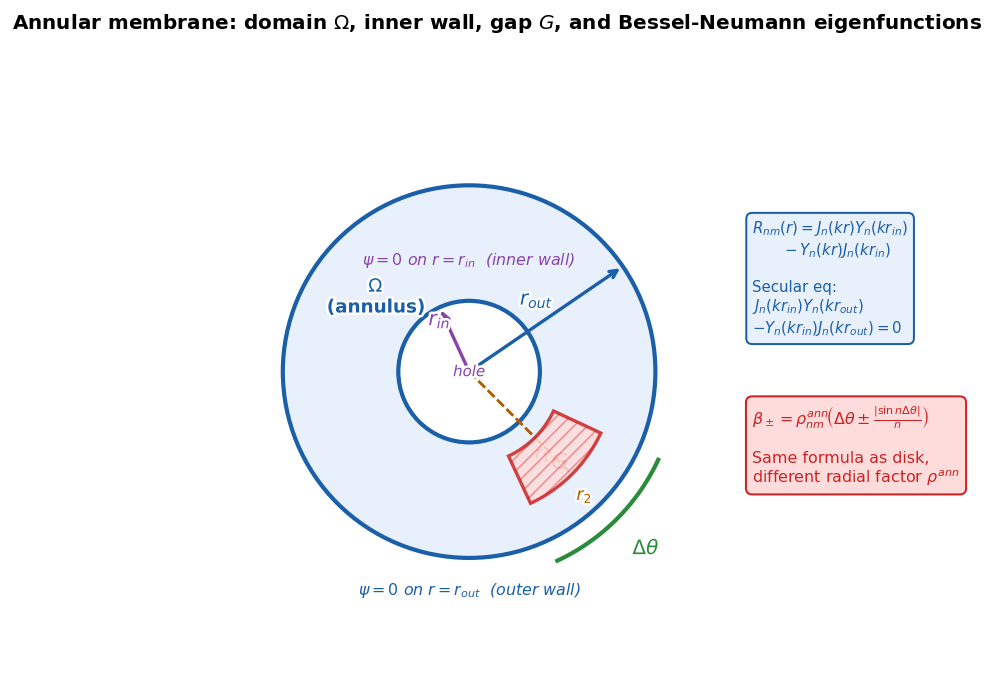

ann OK


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-1.65, 1.95); ax.set_ylim(-1.65, 1.75)
ax.set_aspect('equal'); ax.axis('off')
fig.patch.set_facecolor('white')

r_in=0.38; r_out=1.0; r1,r2=0.50,0.78
theta_t=315*np.pi/180; Dtheta=40*np.pi/180

def label(x, y, txt, **kw):
    kw.setdefault('fontsize', 11); kw.setdefault('ha', 'center'); kw.setdefault('va', 'center')
    t = ax.text(x, y, txt, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t

# Outer disk
outer = plt.Circle((0,0), r_out, color='#e8f0fb', ec='#1a5fa8', lw=2.5, zorder=1)
ax.add_patch(outer)
# Inner hole (white)
inner = plt.Circle((0,0), r_in, color='white', ec='#1a5fa8', lw=2.5, zorder=2)
ax.add_patch(inner)

# Gap sector
th1 = theta_t - Dtheta/2; th2 = theta_t + Dtheta/2
theta_arc = np.linspace(th1, th2, 60)
outer_x = r2*np.cos(theta_arc); outer_y = r2*np.sin(theta_arc)
inner_x = r1*np.cos(theta_arc[::-1]); inner_y = r1*np.sin(theta_arc[::-1])
px = np.concatenate([outer_x, inner_x, [outer_x[0]]])
py = np.concatenate([outer_y, inner_y, [outer_y[0]]])
ax.add_patch(plt.Polygon(list(zip(px,py)), closed=True,
    facecolor='#ffdcdc', edgecolor='#cc2222', lw=2, zorder=4, alpha=0.85))
ax.add_patch(plt.Polygon(list(zip(px,py)), closed=True,
    facecolor='none', edgecolor='#cc2222', hatch='///', lw=0, zorder=5, alpha=0.4))

mid_r=(r1+r2)/2
label(mid_r*np.cos(theta_t)*1.08, mid_r*np.sin(theta_t)*1.08,
      r'$G$', fontsize=13, color='#cc2222', fontweight='bold')

# r_in label
ax.annotate('', xy=(r_in*np.cos(2.0), r_in*np.sin(2.0)),
            xytext=(0,0), arrowprops=dict(arrowstyle='->', color='#8844aa', lw=2))
label(r_in*np.cos(2.0)/2-0.08, r_in*np.sin(2.0)/2+0.10, r'$r_{in}$', fontsize=12, color='#8844aa')

# r_out label
ax.annotate('', xy=(r_out*np.cos(0.6), r_out*np.sin(0.6)),
            xytext=(0,0), arrowprops=dict(arrowstyle='->', color='#1a5fa8', lw=2))
label(r_out*np.cos(0.6)/2-0.05, r_out*np.sin(0.6)/2+0.10, r'$r_{out}$', fontsize=12, color='#1a5fa8')

# r1, r2 dash lines
for ri,lbl in [(r1,r'$r_1$'),(r2,r'$r_2$')]:
    ax.plot([0, ri*np.cos(theta_t)],[0, ri*np.sin(theta_t)],'--',color='#b85c00',lw=1.5,zorder=3)
    label(ri*np.cos(theta_t)*1.12, ri*np.sin(theta_t)*1.12-0.05, lbl, fontsize=10.5, color='#b85c00')

# Δθ arc
arc_r=1.12
arc_th=np.linspace(theta_t-Dtheta/2,theta_t+Dtheta/2,30)
ax.plot(arc_r*np.cos(arc_th),arc_r*np.sin(arc_th),color='#2a8c3a',lw=2.5,zorder=5)
label(arc_r*np.cos(theta_t)*1.20, arc_r*np.sin(theta_t)*1.20,
      r'$\Delta\theta$', fontsize=12, color='#2a8c3a', fontweight='bold')

# Domain label
label(-0.50, 0.40, r'$\Omega$' + '\n(annulus)', fontsize=11, color='#1a5fa8', fontweight='bold')
label(0, 0, r'hole', fontsize=9, color='#8844aa', style='italic')

# Boundary condition labels
ax.text(0, -1.20, r'$\psi = 0$ on $r = r_{out}$  (outer wall)',
        ha='center', fontsize=9.5, color='#1a5fa8', style='italic')
ax.text(0, 0.57, r'$\psi = 0$ on $r = r_{in}$  (inner wall)',
        ha='center', fontsize=9.5, color='#8844aa', style='italic')

# Eigenfunction box
ax.text(1.52, 0.50,
        r'$R_{nm}(r) = J_n(kr)Y_n(kr_{in})$' + '\n' + r'$\quad\quad - Y_n(kr)J_n(kr_{in})$'
        '\n\nSecular eq:\n' r'$J_n(kr_{in})Y_n(kr_{out})$' + '\n' + r'$-Y_n(kr_{in})J_n(kr_{out})=0$',
        fontsize=9, color='#1a5fa8', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f0fb', edgecolor='#1a5fa8', lw=1.2))

ax.text(1.52, -0.40,
        r'$\beta_\pm = \rho^{ann}_{nm}\!\left(\Delta\theta \pm \frac{|\sin n\Delta\theta|}{n}\right)$'
        '\n\nSame formula as disk,\ndifferent radial factor $\\rho^{ann}$',
        fontsize=9.5, color='#cc2222', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffdcdc', edgecolor='#cc2222', lw=1.2))

ax.set_title('Annular membrane: domain $\\Omega$, inner wall, gap $G$, and Bessel-Neumann eigenfunctions',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()
plt.close()
print("ann OK")


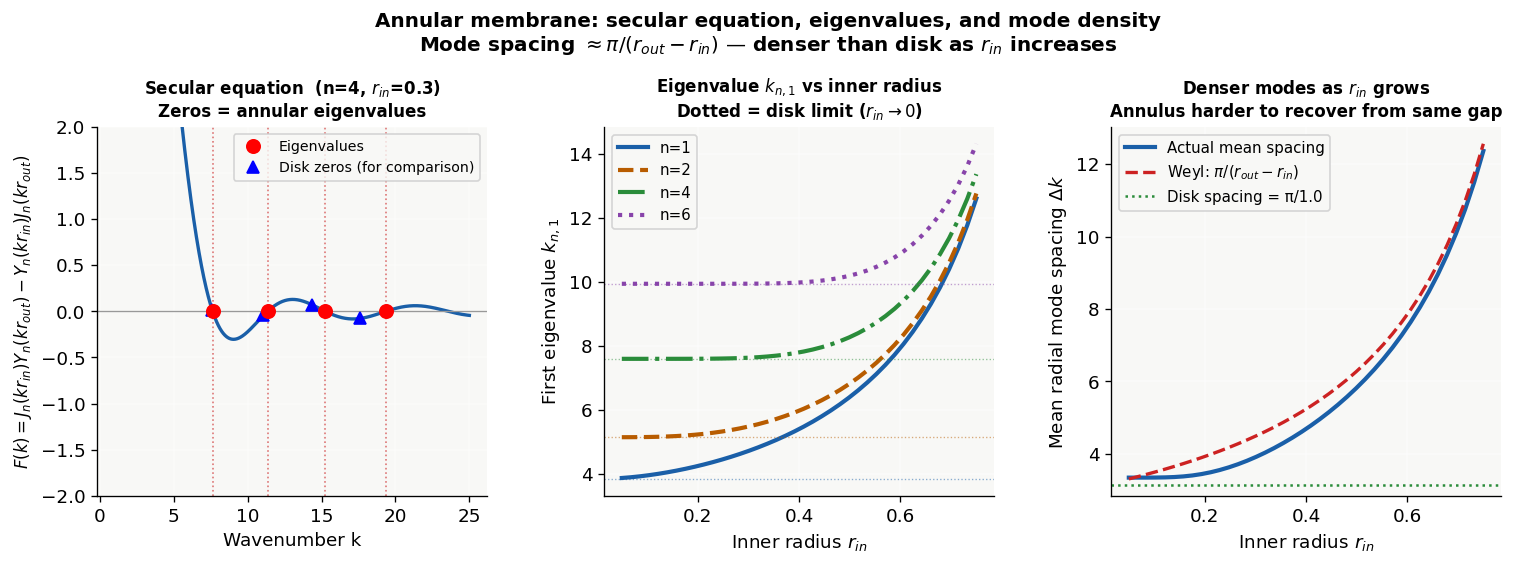

In [3]:
# Figure 1: Secular equation and eigenvalue comparison disk vs annulus

r_out=1.0; r_in_vals=[0.0,0.15,0.30,0.50]; n_show=4

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.07,right=0.97,top=0.78,bottom=0.14,wspace=0.30)

# Panel 1: secular equation F(k) for one annulus
r_in=0.3
k_arr=np.linspace(1,25,2000)
F=secular(k_arr,n_show,r_in,r_out)
ax=axes[0]
ax.plot(k_arr,F,BLUE,lw=2)
ax.axhline(0,color='#999',lw=0.8)
ax.set_ylim(-2,2); ax.set_xlabel('Wavenumber k',fontsize=11)
ax.set_ylabel(r'$F(k) = J_n(kr_{in})Y_n(kr_{out})-Y_n(kr_{in})J_n(kr_{out})$',fontsize=10)
ax.set_title(f'Secular equation  (n={n_show}, $r_{{in}}$={r_in})\nZeros = annular eigenvalues',
             fontsize=10,fontweight='bold')
zeros_=ann_eigenvalues(n_show,r_in,r_out,4)
ax.plot(zeros_,secular(zeros_,n_show,r_in,r_out),'ro',ms=8,zorder=5,label='Eigenvalues')
for z in zeros_:
    ax.axvline(z,color=RED,lw=1,ls=':',alpha=0.6)
# Disk zeros
disk_z=jn_zeros(n_show,4)/r_out
ax.plot(disk_z,secular(disk_z,n_show,r_in,r_out),'b^',ms=7,label='Disk zeros (for comparison)')
ax.legend(fontsize=8.5); ax.grid(True,alpha=0.3)

# Panel 2: first eigenvalue k_{n,1} vs r_in
n_arr=[1,2,4,6]
r_in_range=np.linspace(0.05,0.75,40)
for n_,col,ls in zip(n_arr,[BLUE,AMBER,GREEN,PURP],['-','--','-.',':']):
    k1s=[]
    for ri in r_in_range:
        try: k1s.append(ann_eigenvalues(n_,ri,r_out,1)[0])
        except: k1s.append(np.nan)
    axes[1].plot(r_in_range,k1s,color=col,lw=2.5,ls=ls,label=f'n={n_}')
    # Disk value (horizontal)
    dk=jn_zeros(n_,1)[0]/r_out
    axes[1].axhline(dk,color=col,lw=0.8,ls=':',alpha=0.5)
axes[1].set_xlabel(r'Inner radius $r_{in}$',fontsize=11)
axes[1].set_ylabel(r'First eigenvalue $k_{n,1}$',fontsize=11)
axes[1].set_title('Eigenvalue $k_{n,1}$ vs inner radius\nDotted = disk limit ($r_{in}\\to 0$)',
                  fontsize=10,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.4)

# Panel 3: mode spacing Δk vs r_in (Weyl: spacing ~ π/(r_out-r_in))
for n_,col,ls in zip([4],[BLUE],['-']):
    spacings=[]
    for ri in r_in_range:
        try:
            ks=ann_eigenvalues(n_,ri,r_out,4)
            if len(ks)>=2: spacings.append(np.diff(ks).mean())
            else: spacings.append(np.nan)
        except: spacings.append(np.nan)
    axes[2].plot(r_in_range,spacings,BLUE,lw=2.5,label='Actual mean spacing')

weyl_spacing=np.pi/(r_out-r_in_range)
axes[2].plot(r_in_range,weyl_spacing,RED,lw=2,ls='--',label=r'Weyl: $\pi/(r_{out}-r_{in})$')
disk_spacing=np.pi/r_out
axes[2].axhline(disk_spacing,color=GREEN,lw=1.5,ls=':',label=f'Disk spacing = π/{r_out:.1f}')
axes[2].set_xlabel(r'Inner radius $r_{in}$',fontsize=11)
axes[2].set_ylabel(r'Mean radial mode spacing $\Delta k$',fontsize=11)
axes[2].set_title('Wider spacing as $r_{in}$ grows\nFewer modes per bandwidth in annulus',
                  fontsize=10,fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True,alpha=0.4)

fig.suptitle('Annular membrane: secular equation, eigenvalues, and mode density\n'
             r'Mode spacing $\approx \pi/(r_{out}-r_{in})$ — wider than disk, fewer modes per bandwidth',
             fontsize=12,fontweight='bold')
plt.show()


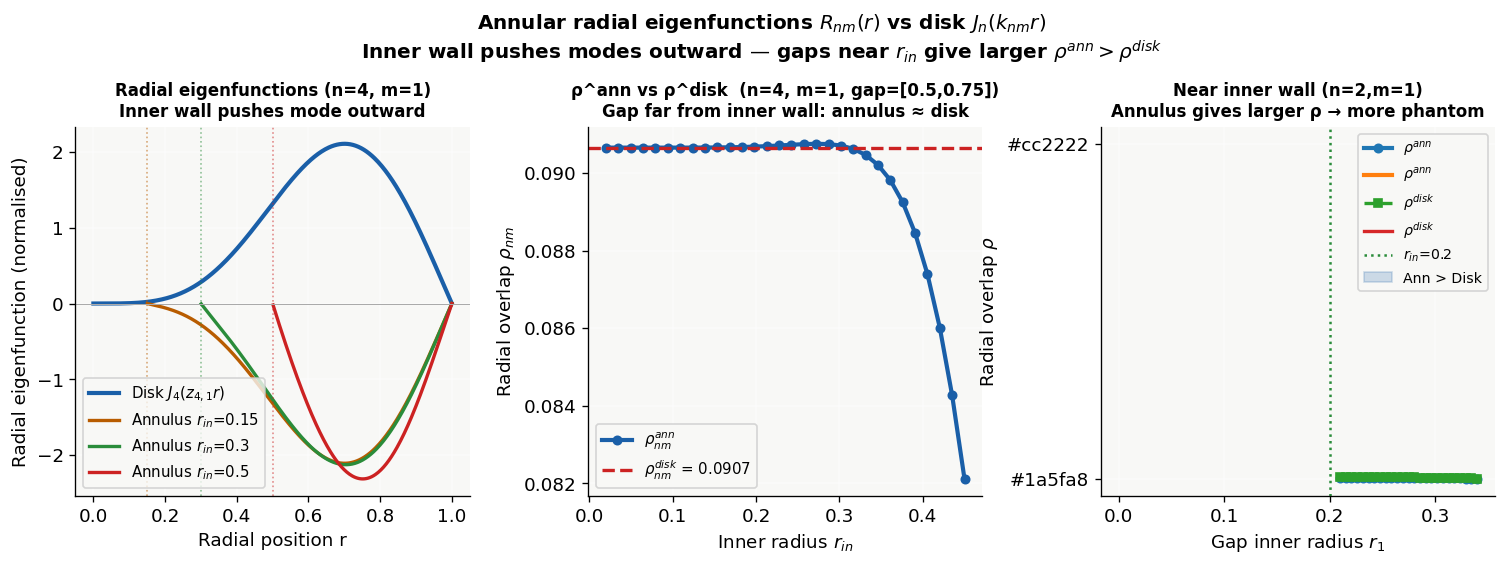

In [4]:
# Figure 2: Radial eigenfunctions R_nm vs J_n (disk) for several r_in

r_out=1.0; n_show=4; r_arr=np.linspace(0.0,r_out,400)

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.06,right=0.97,top=0.78,bottom=0.14,wspace=0.30)

# Panel 1: disk vs annulus radial functions for increasing r_in
ax=axes[0]
# Disk J_4(z_{4,1} r)
z_disk=jn_zeros(n_show,1)[0]
psi_disk=jv(n_show,z_disk*r_arr)
psi_disk/=np.sqrt(np.trapezoid(psi_disk**2*r_arr,r_arr))
ax.plot(r_arr,psi_disk,BLUE,lw=2.5,label='Disk $J_4(z_{4,1}r)$')

colors=[AMBER,GREEN,RED]
for r_in,col in zip([0.15,0.30,0.50],colors):
    k1s=ann_eigenvalues(n_show,r_in,r_out,1)
    if len(k1s)==0: continue
    k1=k1s[0]
    r_plot=r_arr[r_arr>r_in]
    psi=np.array([R_nm(r,k1,n_show,r_in) for r in r_plot])
    norm=np.sqrt(np.trapezoid(psi**2*r_plot,r_plot))
    if norm>0: psi/=norm
    ax.plot(r_plot,psi,col,lw=2,label=f'Annulus $r_{{in}}$={r_in}')
    ax.axvline(r_in,color=col,lw=1,ls=':',alpha=0.5)

ax.axhline(0,color='#aaa',lw=0.6)
ax.set_xlabel('Radial position r',fontsize=11)
ax.set_ylabel('Radial eigenfunction (normalised)',fontsize=11)
ax.set_title(f'Radial eigenfunctions (n={n_show}, m=1)\nInner wall pushes mode outward',
             fontsize=10,fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.4)

# Panel 2: rho^ann vs rho^disk for gap [r1,r2] = [0.5,0.75]
r1_gap,r2_gap=0.5,0.75
from scipy.special import jn_zeros as jnz
r_in_range=np.linspace(0.02,0.45,30)
rho_ann_vals=[]; rho_disk_vals=[]
n_t,m_t=4,1
# Disk rho (fixed)
z_d=jnz(n_t,m_t)[-1]; k_d=z_d/r_out
c2_d=1/(np.pi*r_out**2*jv(n_t+1,z_d)**2)
rho_d,_=quad(lambda r: jv(n_t,k_d*r)**2*r,r1_gap,r2_gap)
rho_disk=c2_d*rho_d

for r_in in r_in_range:
    if r_in>=r1_gap: rho_ann_vals.append(np.nan); continue
    ks=ann_eigenvalues(n_t,r_in,r_out,m_t)
    if len(ks)<m_t: rho_ann_vals.append(np.nan); continue
    k1=ks[m_t-1]
    rv=rho_ann(n_t,k1,r_in,r_out,r1_gap,r2_gap)
    rho_ann_vals.append(rv)
    rho_disk_vals.append(rho_disk)

axes[1].plot(r_in_range,rho_ann_vals,'o-',color=BLUE,lw=2.5,ms=5,label=r'$\rho^{ann}_{nm}$')
axes[1].axhline(rho_disk,color=RED,lw=2,ls='--',label=f'$\\rho^{{disk}}_{{nm}}$ = {rho_disk:.4f}')
axes[1].set_xlabel(r'Inner radius $r_{in}$',fontsize=11)
axes[1].set_ylabel(r'Radial overlap $\rho_{nm}$',fontsize=11)
axes[1].set_title(f'ρ^ann vs ρ^disk  (n={n_t}, m={m_t}, gap=[{r1_gap},{r2_gap}])\n'
                  'Gap far from inner wall: annulus ≈ disk',fontsize=10,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.4)

# Panel 3: near-inner-wall gap — annulus > disk
r2_near=0.35; r_in2=0.20; n_t2,m_t2=2,1
r1_near_vals=np.linspace(r_in2+0.01,r2_near-0.01,25)
rho_ann_near=[]; rho_disk_near=[]
z_d2=jnz(n_t2,m_t2)[-1]; k_d2=z_d2/r_out
c2_d2=1/(np.pi*r_out**2*jv(n_t2+1,z_d2)**2)
ks2=ann_eigenvalues(n_t2,r_in2,r_out,m_t2)
k_a2=ks2[m_t2-1] if len(ks2)>=m_t2 else None
for r1n in r1_near_vals:
    rd,_=quad(lambda r: jv(n_t2,k_d2*r)**2*r,r1n,r2_near)
    rho_disk_near.append(c2_d2*rd)
    if k_a2:
        ra=rho_ann(n_t2,k_a2,r_in2,r_out,r1n,r2_near)
        rho_ann_near.append(ra)
    else:
        rho_ann_near.append(np.nan)

axes[2].plot(r1_near_vals,rho_ann_near,'o-',BLUE,lw=2.5,ms=5,label=r'$\rho^{ann}$')
axes[2].plot(r1_near_vals,rho_disk_near,'s--',RED,lw=2,ms=5,label=r'$\rho^{disk}$')
axes[2].axvline(r_in2,color=GREEN,lw=1.5,ls=':',label=f'$r_{{in}}$={r_in2}')
axes[2].fill_between(r1_near_vals,rho_ann_near,rho_disk_near,
                     where=[a>b for a,b in zip(rho_ann_near,rho_disk_near)],
                     alpha=0.2,color=BLUE,label='Ann > Disk')
axes[2].set_xlabel(r'Gap inner radius $r_1$',fontsize=11)
axes[2].set_ylabel(r'Radial overlap $\rho$',fontsize=11)
axes[2].set_title(f'Near inner wall (n={n_t2},m={m_t2})\nAnnulus gives larger ρ → more phantom',
                  fontsize=10,fontweight='bold')
axes[2].legend(fontsize=8.5); axes[2].grid(True,alpha=0.4)

fig.suptitle(r'Annular radial eigenfunctions $R_{nm}(r)$ vs disk $J_n(k_{nm}r)$' + '\n'
             r'Inner wall pushes modes outward — gaps near $r_{in}$ give larger $\rho^{ann} > \rho^{disk}$',
             fontsize=12,fontweight='bold')
plt.show()


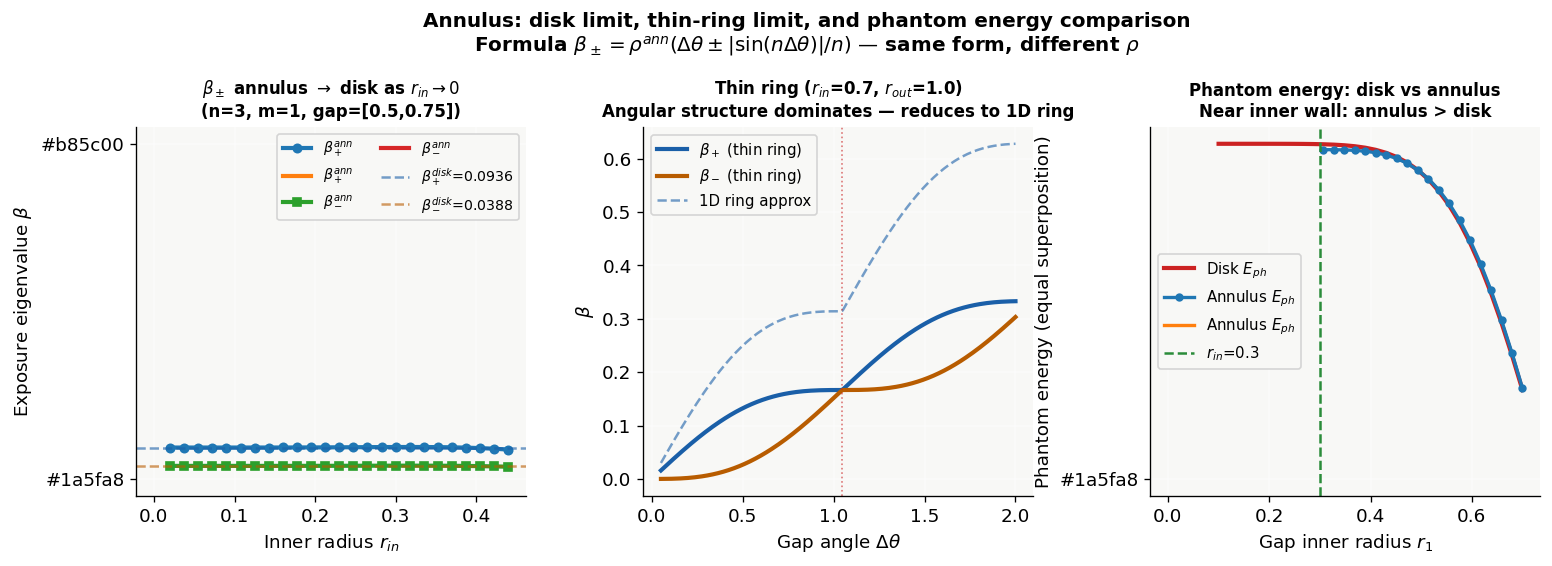

In [5]:
# Figure 3: Disk limit, thin-ring limit, and β± comparison

r_out=1.0; n_show=3; Delta_theta=np.radians(40)
theta_t=np.pi/4; r1_gap,r2_gap=0.5,0.75

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.07,right=0.97,top=0.78,bottom=0.14,wspace=0.30)

# Panel 1: β± annulus vs disk as r_in varies
from scipy.special import jn_zeros as jnz
r_in_range=np.linspace(0.02,0.44,25)
bp_ann=[]; bm_ann=[]
# Disk β±
z_d=jnz(n_show,1)[-1]; k_d=z_d/r_out
c2_d=1/(np.pi*r_out**2*jv(n_show+1,z_d)**2)
rho_d,_=quad(lambda r: jv(n_show,k_d*r)**2*r,r1_gap,r2_gap)
rho_disk=c2_d*rho_d
split=abs(np.sin(n_show*Delta_theta))/n_show
bp_disk=rho_disk*(Delta_theta+split); bm_disk=rho_disk*(Delta_theta-split)

for r_in in r_in_range:
    if r_in>=r1_gap: bp_ann.append(np.nan); bm_ann.append(np.nan); continue
    ks=ann_eigenvalues(n_show,r_in,r_out,1)
    if not ks: bp_ann.append(np.nan); bm_ann.append(np.nan); continue
    bp,bm,_=beta_pm_ann(n_show,ks[0],r_in,r_out,r1_gap,r2_gap,Delta_theta)
    bp_ann.append(bp); bm_ann.append(bm)

axes[0].plot(r_in_range,bp_ann,'o-',BLUE,lw=2.5,ms=5,label=r'$\beta_+^{ann}$')
axes[0].plot(r_in_range,bm_ann,'s-',AMBER,lw=2.5,ms=5,label=r'$\beta_-^{ann}$')
axes[0].axhline(bp_disk,color=BLUE,lw=1.5,ls='--',alpha=0.6,label=f'$\\beta_+^{{disk}}$={bp_disk:.4f}')
axes[0].axhline(bm_disk,color=AMBER,lw=1.5,ls='--',alpha=0.6,label=f'$\\beta_-^{{disk}}$={bm_disk:.4f}')
axes[0].set_xlabel(r'Inner radius $r_{in}$',fontsize=11)
axes[0].set_ylabel(r'Exposure eigenvalue $\beta$',fontsize=11)
axes[0].set_title(r'$\beta_\pm$ annulus $\to$ disk as $r_{in}\to 0$' + '\n'
                  f'(n={n_show}, m=1, gap=[{r1_gap},{r2_gap}])',fontsize=10,fontweight='bold')
axes[0].legend(fontsize=8.5,ncol=2); axes[0].grid(True,alpha=0.4)

# Panel 2: thin-ring limit — β vs Δθ for full-width radial gap
# Full-width radial gap: ρ = 1/(2π) exactly, INDEPENDENT of δ (complex-basis normalization).
# So β±(Δθ) = (1/(2π))(Δθ ± |sin(nΔθ)|/n), up to small radial-confinement corrections.
r_in_thin=0.70; r_out_thin=1.0; delta_r=r_out_thin-r_in_thin
Delta_vals=np.linspace(0.05,2.0,200)
n_ring=3
ks_thin=ann_eigenvalues(n_ring,r_in_thin,r_out_thin,1)
if ks_thin:
    k_thin=ks_thin[0]
    bp_thin=[]; bm_thin=[]
    for D in Delta_vals:
        bp,bm,rho=beta_pm_ann(n_ring,k_thin,r_in_thin,r_out_thin,
                               r_in_thin+0.001,r_out_thin-0.001,D)
        bp_thin.append(bp); bm_thin.append(bm)
    axes[1].plot(Delta_vals,bp_thin,BLUE,lw=2.5,label=r'$\beta_+$ (exact, full-width gap)')
    axes[1].plot(Delta_vals,bm_thin,AMBER,lw=2.5,label=r'$\beta_-$ (exact, full-width gap)')
    # Thin-ring effective 1D ring model: ρ_eff = 1/(2π), independent of δ
    rho_ring_approx=1.0/(2*np.pi)
    bp_ring=[rho_ring_approx*(D+abs(np.sin(n_ring*D))/n_ring) for D in Delta_vals]
    bm_ring=[rho_ring_approx*(D-abs(np.sin(n_ring*D))/n_ring) for D in Delta_vals]
    axes[1].plot(Delta_vals,bp_ring,BLUE,lw=1.5,ls='--',alpha=0.6,label=r'1D ring model: $\rho=1/(2\pi)$')

# Mark blindness
for k_bl in range(1,5):
    D_bl=k_bl*np.pi/n_ring
    if D_bl<2.0: axes[1].axvline(D_bl,color=RED,lw=1,ls=':',alpha=0.6)
axes[1].set_xlabel(r'Gap angle $\Delta\theta$',fontsize=11); axes[1].set_ylabel(r'$\beta$',fontsize=11)
axes[1].set_title(f'Thin ring ($r_{{in}}$={r_in_thin}, $r_{{out}}$={r_out_thin})\n'
                  'Angular structure dominates — effective 1D ring at lowest radial mode',fontsize=10,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.4)

# Panel 3: phantom energy comparison disk vs annulus over gap positions
n_comp,m_comp=4,1
r2_fixed=0.75; r1_vals=np.linspace(0.1,0.70,30)
r_in_comp=0.30
ks_comp=ann_eigenvalues(n_comp,r_in_comp,r_out,1)
k_comp=ks_comp[0] if ks_comp else None
z_comp=jnz(n_comp,m_comp)[-1]; k_disk_c=z_comp/r_out
c2_dc=1/(np.pi*r_out**2*jv(n_comp+1,z_comp)**2)
Eph_ann=[]; Eph_disk=[]
split_c=abs(np.sin(n_comp*Delta_theta))/n_comp
for r1 in r1_vals:
    if r1>=r2_fixed or r1<=r_in_comp:
        Eph_ann.append(np.nan)
    else:
        bp,bm,_=beta_pm_ann(n_comp,k_comp,r_in_comp,r_out,r1,r2_fixed,Delta_theta)
        Eph_ann.append(0.5*(bp*(1-bp)+bm*(1-bm)))
    rd,_=quad(lambda r: jv(n_comp,k_disk_c*r)**2*r,r1,r2_fixed)
    rho_d_c=c2_dc*rd
    bp_d=rho_d_c*(Delta_theta+split_c); bm_d=rho_d_c*(Delta_theta-split_c)
    Eph_disk.append(0.5*(bp_d*(1-bp_d)+bm_d*(1-bm_d)))

axes[2].plot(r1_vals,Eph_disk,RED,lw=2.5,label=r'Disk $E_{ph}$')
axes[2].plot(r1_vals,Eph_ann,'o-',BLUE,lw=2,ms=4,label=r'Annulus $E_{ph}$')
axes[2].axvline(r_in_comp,color=GREEN,lw=1.5,ls='--',label=f'$r_{{in}}$={r_in_comp}')
axes[2].fill_between(r1_vals,Eph_ann,Eph_disk,
                     where=[a>b if (a and b) else False for a,b in zip(Eph_ann,Eph_disk)],
                     alpha=0.15,color=BLUE)
axes[2].set_xlabel(r'Gap inner radius $r_1$',fontsize=11)
axes[2].set_ylabel('Phantom energy (equal superposition)',fontsize=11)
axes[2].set_title('Phantom energy: disk vs annulus\nNear inner wall: annulus > disk',
                  fontsize=10,fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True,alpha=0.4)

fig.suptitle('Annulus: disk limit, thin-ring limit, and phantom energy comparison\n'
             r'Formula $\beta_\pm = \rho^{ann}(\Delta\theta \pm |\sin(n\Delta\theta)|/n)$ — same form, different $\rho$',
             fontsize=12,fontweight='bold')
plt.show()
